In [1]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"

import random
from pathlib import Path

import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf
import keras

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

DATA_DIR = Path("../data")
IMAGES_DIR = DATA_DIR / "images"
MASKS_DIR = DATA_DIR / "masks"
CSV_PATH = DATA_DIR / "GroundTruth.csv"

TEST_SIZE = 0.20

classes = ["MEL", "NV", "BCC", "AKIEC", "BKL", "DF", "VASC"]
class_code = {label: idx for idx, label in enumerate(classes)}
class_name = {idx: label for label, idx in class_code.items()}

print(class_code)

{'MEL': 0, 'NV': 1, 'BCC': 2, 'AKIEC': 3, 'BKL': 4, 'DF': 5, 'VASC': 6}


In [3]:
for file in os.listdir():
    if file.endswith(".keras"):
        print(file)

encoder_decoder_segmenter.keras
segmented_densenet169_dull_smote_final.keras
best_densenet169_dull_crop_smote.keras
best_deepskin_densenet169_undersampling.keras
best_segmented_densenet169_dull_smote.keras
segmented_densenet169_feature_extractor.keras
deepskin_densenet169_undersampling_final.keras
best_segmented_densenet169_dull_undersampling.keras
densenet169_dull_crop_feature_extractor.keras
densenet169_feature_extractor.keras
densenet201_crop_320_feature_extractor.keras
segmented_densenet169_dull_undersampling_final.keras
densenet201_crop_smote_256_final.keras
best_densenet169_undersampling.keras
deepskin_densenet169_smote_final.keras
best_densenet201_crop_smote_320.keras
densenet169_dull_crop_smote_final.keras
best_deepskin_densenet169_smote.keras


In [4]:
# Modelo A: DenseNet201 + Crop + SMOTE + 320x320 + TTA
IMG_SIZE_A = (320, 320)
FEATURE_EXTRACTOR_A_PATH = "densenet201_crop_320_feature_extractor.keras"
CLASSIFIER_A_PATH = "best_densenet201_crop_smote_320.keras"

# Modelo B: DenseNet169 + Crop + SMOTE + 256x256 + TTA
IMG_SIZE_B = (256, 256)
FEATURE_EXTRACTOR_B_PATH = "densenet169_dull_crop_feature_extractor.keras"
CLASSIFIER_B_PATH = "best_densenet169_dull_crop_smote.keras"

USE_DULL_RAZOR = False
USE_MASK_SEGMENTATION = False
USE_MASK_CROP = True
CROP_MARGIN = 20

WEIGHT_MODEL_A = 0.8
WEIGHT_MODEL_B = 0.2

print("Modelo A:", IMG_SIZE_A, FEATURE_EXTRACTOR_A_PATH, CLASSIFIER_A_PATH)
print("Modelo B:", IMG_SIZE_B, FEATURE_EXTRACTOR_B_PATH, CLASSIFIER_B_PATH)
print("Pesos:", WEIGHT_MODEL_A, WEIGHT_MODEL_B)

assert abs((WEIGHT_MODEL_A + WEIGHT_MODEL_B) - 1.0) < 1e-6, "Os pesos devem somar 1."

Modelo A: (320, 320) densenet201_crop_320_feature_extractor.keras best_densenet201_crop_smote_320.keras
Modelo B: (256, 256) densenet169_dull_crop_feature_extractor.keras best_densenet169_dull_crop_smote.keras
Pesos: 0.8 0.2


In [5]:
def find_image_path(image_id, images_dir):
    for ext in [".jpg", ".jpeg", ".png"]:
        path = images_dir / f"{image_id}{ext}"
        if path.exists():
            return str(path)
    return None


def find_mask_path(image_id, masks_dir):
    if not masks_dir.exists():
        return None

    candidates = [
        masks_dir / f"{image_id}_segmentation.png",
        masks_dir / f"{image_id}_segmentation.jpg",
        masks_dir / f"{image_id}_mask.png",
        masks_dir / f"{image_id}_mask.jpg",
        masks_dir / f"{image_id}.png",
        masks_dir / f"{image_id}.jpg",
    ]

    for path in candidates:
        if path.exists():
            return str(path)

    matches = list(masks_dir.glob(f"{image_id}*"))
    if len(matches) > 0:
        return str(matches[0])

    return None


metadata = pd.read_csv(CSV_PATH)

rows = []
for _, row in metadata.iterrows():
    image_id = str(row["image"])
    image_path = find_image_path(image_id, IMAGES_DIR)
    mask_path = find_mask_path(image_id, MASKS_DIR)

    if image_path is None:
        continue

    label_name = row[classes].idxmax()
    label = class_code[label_name]

    rows.append({
        "image": image_id,
        "image_path": image_path,
        "mask_path": mask_path,
        "class_name": label_name,
        "label": label
    })

df = pd.DataFrame(rows)

train_df, test_df = train_test_split(
    df,
    test_size=TEST_SIZE,
    random_state=SEED,
    stratify=df["label"]
)

print("Total:", len(df))
print("Teste:", len(test_df))
print(test_df["class_name"].value_counts().reindex(classes))

Total: 10015
Teste: 2003
class_name
MEL       223
NV       1341
BCC       103
AKIEC      65
BKL       220
DF         23
VASC       28
Name: count, dtype: int64


In [6]:
def read_rgb_image(path):
    if isinstance(path, bytes):
        path = path.decode("utf-8")

    image_bgr = cv2.imread(str(path), cv2.IMREAD_COLOR)

    if image_bgr is None:
        raise ValueError(f"Não foi possível carregar a imagem: {path}")

    return cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)


def dull_razor_remove_hair(image_rgb, kernel_size=(9, 9), threshold_value=10, inpaint_radius=6):
    image_rgb = image_rgb.astype(np.uint8)
    gray = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2GRAY)

    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, kernel_size)
    blackhat = cv2.morphologyEx(gray, cv2.MORPH_BLACKHAT, kernel)
    blackhat_blur = cv2.GaussianBlur(blackhat, (3, 3), 0)

    _, mask = cv2.threshold(blackhat_blur, threshold_value, 255, cv2.THRESH_BINARY)

    image_bgr = cv2.cvtColor(image_rgb, cv2.COLOR_RGB2BGR)
    clean_bgr = cv2.inpaint(image_bgr, mask, inpaint_radius, cv2.INPAINT_TELEA)

    return cv2.cvtColor(clean_bgr, cv2.COLOR_BGR2RGB)


def read_binary_mask(mask_path, target_shape):
    if mask_path is None or pd.isna(mask_path):
        return None

    if isinstance(mask_path, bytes):
        mask_path = mask_path.decode("utf-8")

    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)

    if mask is None:
        return None

    height, width = target_shape[:2]
    mask = cv2.resize(mask, (width, height))

    return (mask > 127).astype(np.uint8)


def apply_mask_segmentation(image_rgb, mask_path):
    binary_mask = read_binary_mask(mask_path, target_shape=image_rgb.shape)

    if binary_mask is None:
        return image_rgb

    segmented = image_rgb * np.expand_dims(binary_mask, axis=-1)

    if np.mean(segmented) < 5:
        return image_rgb

    return segmented


def crop_lesion_with_margin(image_rgb, mask_path, margin=20):
    binary_mask = read_binary_mask(mask_path, target_shape=image_rgb.shape)

    if binary_mask is None:
        return image_rgb

    ys, xs = np.where(binary_mask > 0)

    if len(xs) == 0 or len(ys) == 0:
        return image_rgb

    height, width = image_rgb.shape[:2]

    x_min = max(xs.min() - margin, 0)
    x_max = min(xs.max() + margin, width - 1)
    y_min = max(ys.min() - margin, 0)
    y_max = min(ys.max() + margin, height - 1)

    cropped = image_rgb[y_min:y_max + 1, x_min:x_max + 1]

    if cropped.size == 0:
        return image_rgb

    return cropped


def preprocess_image_path_for_size(path, mask_path=None, img_size=(256, 256)):
    image_rgb = read_rgb_image(path)

    if USE_DULL_RAZOR:
        image_rgb = dull_razor_remove_hair(image_rgb)

    if USE_MASK_CROP:
        image_rgb = crop_lesion_with_margin(image_rgb, mask_path, margin=CROP_MARGIN)
    elif USE_MASK_SEGMENTATION:
        image_rgb = apply_mask_segmentation(image_rgb, mask_path)

    image_rgb = cv2.resize(image_rgb, img_size)

    return image_rgb.astype("float32")

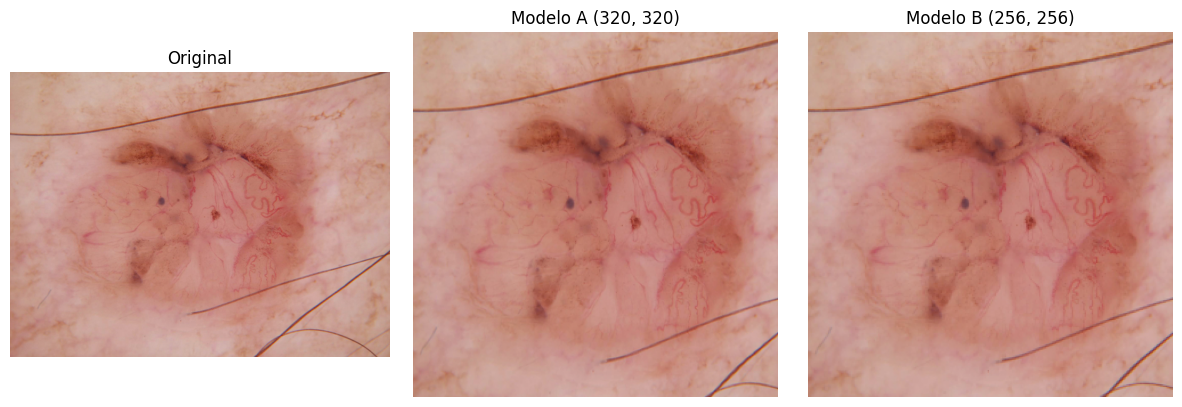

In [7]:
sample_row = test_df.sample(1, random_state=SEED).iloc[0]

original = read_rgb_image(sample_row["image_path"])
processed_a = preprocess_image_path_for_size(sample_row["image_path"], sample_row["mask_path"], img_size=IMG_SIZE_A)
processed_b = preprocess_image_path_for_size(sample_row["image_path"], sample_row["mask_path"], img_size=IMG_SIZE_B)

plt.figure(figsize=(12, 4))

plt.subplot(1, 3, 1)
plt.imshow(original)
plt.title("Original")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(np.clip(processed_a, 0, 255).astype("uint8"))
plt.title(f"Modelo A {IMG_SIZE_A}")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(np.clip(processed_b, 0, 255).astype("uint8"))
plt.title(f"Modelo B {IMG_SIZE_B}")
plt.axis("off")

plt.tight_layout()
plt.savefig("ensemble_preprocessamento_exemplo.png", dpi=300, bbox_inches="tight")
plt.show()

In [8]:
feature_extractor_a = keras.models.load_model(FEATURE_EXTRACTOR_A_PATH)
classifier_a = keras.models.load_model(CLASSIFIER_A_PATH)

feature_extractor_b = keras.models.load_model(FEATURE_EXTRACTOR_B_PATH)
classifier_b = keras.models.load_model(CLASSIFIER_B_PATH)

print("Modelo A input:", feature_extractor_a.input_shape)
print("Modelo B input:", feature_extractor_b.input_shape)

Modelo A input: (None, 320, 320, 3)
Modelo B input: (None, 256, 256, 3)


In [9]:
def generate_tta_images(image):
    image = image.astype("float32")
    return np.array([
        image,
        np.fliplr(image),
        np.flipud(image),
        np.flipud(np.fliplr(image)),
    ], dtype="float32")


def predict_model_with_tta(image_path, mask_path, img_size, feature_extractor, classifier):
    image = preprocess_image_path_for_size(image_path, mask_path, img_size=img_size)
    tta_images = generate_tta_images(image)

    features = feature_extractor.predict(tta_images, verbose=0)
    preds = classifier.predict(features, verbose=0)

    return np.mean(preds, axis=0)


def predict_ensemble_tta(image_path, mask_path):
    pred_a = predict_model_with_tta(
        image_path=image_path,
        mask_path=mask_path,
        img_size=IMG_SIZE_A,
        feature_extractor=feature_extractor_a,
        classifier=classifier_a
    )

    pred_b = predict_model_with_tta(
        image_path=image_path,
        mask_path=mask_path,
        img_size=IMG_SIZE_B,
        feature_extractor=feature_extractor_b,
        classifier=classifier_b
    )

    final_pred = (WEIGHT_MODEL_A * pred_a) + (WEIGHT_MODEL_B * pred_b)

    return final_pred

In [10]:
sample_row = test_df.iloc[0]

sample_pred = predict_ensemble_tta(sample_row["image_path"], sample_row["mask_path"])

print("Shape:", sample_pred.shape)
print("Soma:", sample_pred.sum())
print("Classe real:", sample_row["class_name"])
print("Classe predita:", class_name[int(np.argmax(sample_pred))])

Shape: (7,)
Soma: 1.0000001
Classe real: NV
Classe predita: NV


In [11]:
y_true_ensemble = []
y_pred_ensemble = []

for _, row in test_df.reset_index(drop=True).iterrows():
    pred = predict_ensemble_tta(row["image_path"], row["mask_path"])
    pred_class = np.argmax(pred)

    y_true_ensemble.append(int(row["label"]))
    y_pred_ensemble.append(pred_class)

y_true_ensemble = np.array(y_true_ensemble)
y_pred_ensemble = np.array(y_pred_ensemble)

print("Avaliação com ensemble concluída.")

Avaliação com ensemble concluída.


In [12]:
print("Relatório de Classificação do Ensemble:")
print(classification_report(
    y_true_ensemble,
    y_pred_ensemble,
    target_names=classes,
    digits=4,
    zero_division=0
))

acc_ensemble = accuracy_score(y_true_ensemble, y_pred_ensemble)

macro_precision_ensemble = precision_score(y_true_ensemble, y_pred_ensemble, average="macro", zero_division=0)
macro_recall_ensemble = recall_score(y_true_ensemble, y_pred_ensemble, average="macro", zero_division=0)
macro_f1_ensemble = f1_score(y_true_ensemble, y_pred_ensemble, average="macro", zero_division=0)

weighted_precision_ensemble = precision_score(y_true_ensemble, y_pred_ensemble, average="weighted", zero_division=0)
weighted_recall_ensemble = recall_score(y_true_ensemble, y_pred_ensemble, average="weighted", zero_division=0)
weighted_f1_ensemble = f1_score(y_true_ensemble, y_pred_ensemble, average="weighted", zero_division=0)

print("\nMÉTRICAS GERAIS DO ENSEMBLE")
print(f"Accuracy: {acc_ensemble:.4f}")

print("\nMacro Average:")
print(f"  Precision: {macro_precision_ensemble:.4f}")
print(f"  Recall: {macro_recall_ensemble:.4f}")
print(f"  F1-Score: {macro_f1_ensemble:.4f}")

print("\nWeighted Average:")
print(f"  Precision: {weighted_precision_ensemble:.4f}")
print(f"  Recall: {weighted_recall_ensemble:.4f}")
print(f"  F1-Score: {weighted_f1_ensemble:.4f}")

Relatório de Classificação do Ensemble:
              precision    recall  f1-score   support

         MEL     0.7217    0.6861    0.7034       223
          NV     0.9276    0.9553    0.9412      1341
         BCC     0.7603    0.8932    0.8214       103
       AKIEC     0.6562    0.6462    0.6512        65
         BKL     0.7912    0.6545    0.7164       220
          DF     0.9444    0.7391    0.8293        23
        VASC     0.9600    0.8571    0.9057        28

    accuracy                         0.8752      2003
   macro avg     0.8231    0.7759    0.7955      2003
weighted avg     0.8729    0.8752    0.8727      2003


MÉTRICAS GERAIS DO ENSEMBLE
Accuracy: 0.8752

Macro Average:
  Precision: 0.8231
  Recall: 0.7759
  F1-Score: 0.7955

Weighted Average:
  Precision: 0.8729
  Recall: 0.8752
  F1-Score: 0.8727


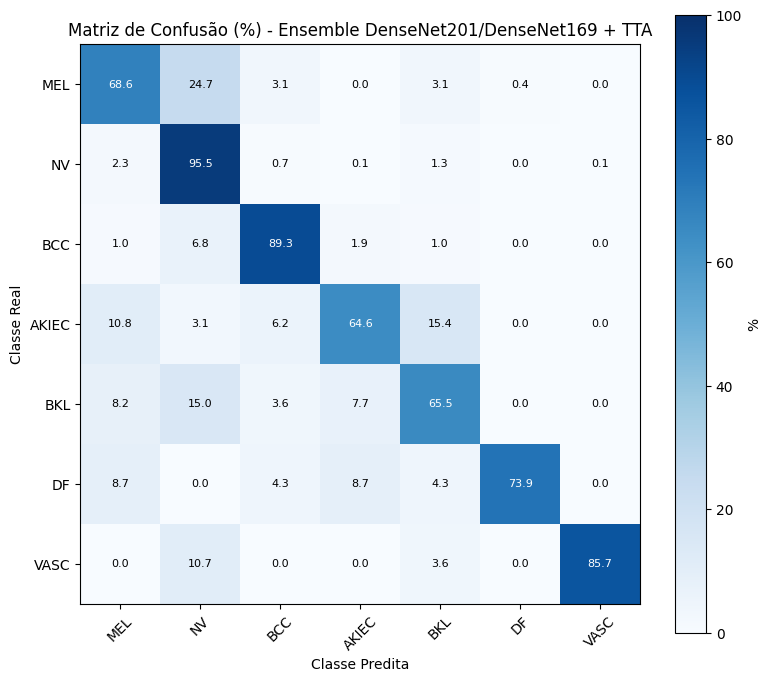

In [13]:
cm_ensemble = confusion_matrix(y_true_ensemble, y_pred_ensemble, labels=list(range(len(classes))))
cm_percent_ensemble = cm_ensemble.astype("float") / cm_ensemble.sum(axis=1, keepdims=True) * 100
cm_percent_ensemble = np.nan_to_num(cm_percent_ensemble)

plt.figure(figsize=(8, 7))
im = plt.imshow(cm_percent_ensemble, interpolation="nearest", cmap="Blues", vmin=0, vmax=100)

plt.title("Matriz de Confusão (%) - Ensemble DenseNet201/DenseNet169 + TTA")
plt.colorbar(im, label="%")

tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)

for i in range(cm_percent_ensemble.shape[0]):
    for j in range(cm_percent_ensemble.shape[1]):
        color = "white" if cm_percent_ensemble[i, j] > 50 else "black"
        plt.text(
            j,
            i,
            f"{cm_percent_ensemble[i, j]:.1f}",
            ha="center",
            va="center",
            color=color,
            fontsize=8
        )

plt.ylabel("Classe Real")
plt.xlabel("Classe Predita")
plt.tight_layout()
plt.savefig("matriz_confusao_percent_ensemble_densenet201_densenet169_tta.png", dpi=300, bbox_inches="tight")
plt.show()

In [14]:
print("Melhor modelo individual atual:")
print("DenseNet201 + Crop + SMOTE + 320x320 + TTA")
print("Accuracy: 0.8662")
print("F1 macro: 0.7758")
print("F1 ponderado: 0.8647")

print("\nResultado do ensemble:")
print(f"Accuracy: {acc_ensemble:.4f}")
print(f"F1 macro: {macro_f1_ensemble:.4f}")
print(f"F1 ponderado: {weighted_f1_ensemble:.4f}")

print("\nPesos usados:")
print(f"Modelo A: {WEIGHT_MODEL_A}")
print(f"Modelo B: {WEIGHT_MODEL_B}")

Melhor modelo individual atual:
DenseNet201 + Crop + SMOTE + 320x320 + TTA
Accuracy: 0.8662
F1 macro: 0.7758
F1 ponderado: 0.8647

Resultado do ensemble:
Accuracy: 0.8752
F1 macro: 0.7955
F1 ponderado: 0.8727

Pesos usados:
Modelo A: 0.8
Modelo B: 0.2
